In [ ]:
from utils.ontology_model_fns import *

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ontologies = ['cl']

for ontology in ontologies:
    ograph = load_ontology_graph(obo_folder="obo_files/", ontology_name=ontology)
    n2vmodel = make_node2vec_model(ograph,dimensions=512, workers=4, batch_words=256)
    n2vmodel.save(f"obo_models/{ontology}_node2vec.model")

Computing transition probabilities: 100%|██████████| 17053/17053 [00:01<00:00, 16526.85it/s]
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
Generating walks (CPU: 1):   4%|▍         | 2/50 [00:00<00:09,  5.21it/s]/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
Generating walks (CPU: 2):   4%|▍         | 2/50 [00:00<00:09,  4.99it/s]/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
Generating walks (CPU: 2):   8%|▊         | 4/50 [00:

KeyboardInterrupt: 

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


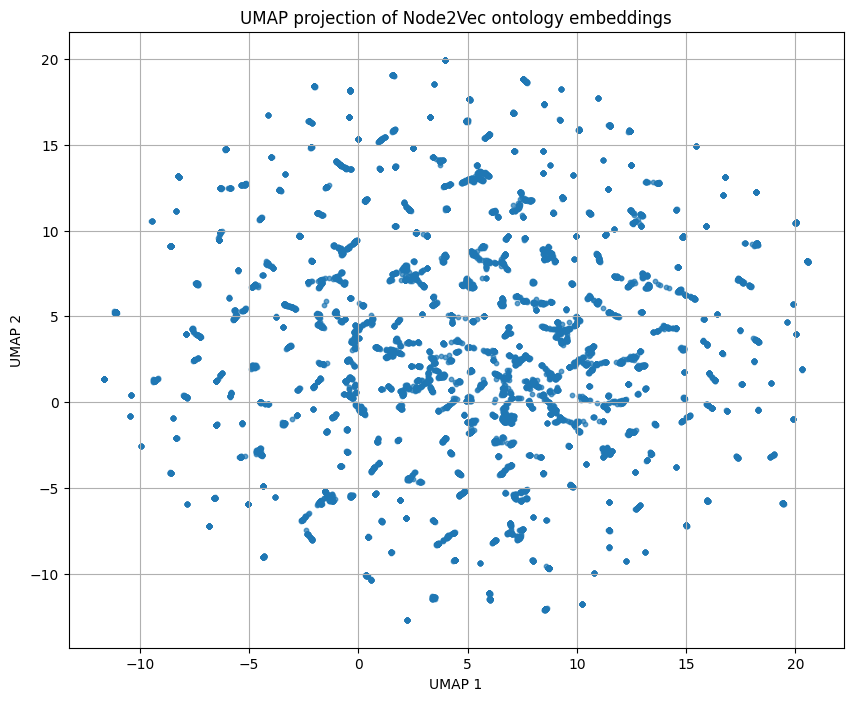

In [ ]:
from umap import UMAP
import matplotlib.pyplot as plt
import numpy as np

from gensim.models import Word2Vec

model = Word2Vec.load("obo_models/doid_node2vec.model")

# Step 1: Extract node embeddings
nodes = list(model.wv.index_to_key)  # all node IDs (strings)
embeddings = np.array([model.wv[node] for node in nodes])  # shape (n_nodes, d)

# Step 2: UMAP projection
umap_model = UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
umap_coords = umap_model.fit_transform(embeddings)  # shape (n_nodes, 2)

# Step 3: Plot
plt.figure(figsize=(10, 8))
plt.scatter(umap_coords[:, 0], umap_coords[:, 1], s=10, alpha=0.7)
plt.title("UMAP projection of Node2Vec ontology embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

## Subgraph testing

In [34]:
import obonet
import networkx as nx

cl_graph = obonet.read_obo("obo_files/cl.obo")  # full Cell Ontology

hematopoietic_root = "CL:0000988"  # immune cell example, replace if needed

def get_subtree(graph, root):
    """
    Return all nodes and edges in the subtree rooted at `root`.
    Assumes graph edges go parent -> child.
    """
    nodes = set()
    edges = []

    def dfs(node):
        if node in nodes:
            return
        nodes.add(node)
        for child in graph.successors(node):
            edges.append((node, child))
            dfs(child)

    dfs(root)
    return graph.subgraph(nodes).copy()


# Build subtree
immune_subgraph = get_subtree(cl_graph.reverse(), hematopoietic_root)

print("Nodes:", immune_subgraph.number_of_nodes())
print("Edges:", immune_subgraph.number_of_edges())

# Example: print first few
for node in list(immune_subgraph.nodes):
    if "CL:" in node:
        print(node, immune_subgraph.nodes[node].get("name", "N/A"))

Nodes: 4469
Edges: 9292
CL:0002585 retinal blood vessel endothelial cell
CL:0004241 WF2 amacrine cell
CL:0000766 myeloid leukocyte
CL:0002429 CD69-positive double-positive thymocyte
CL:0002110 B220-low CD38-positive naive B cell
CL:0000768 immature basophil
CL:1001124 kidney cortex peritubular capillary cell
CL:0000542 lymphocyte
CL:4033038 lung resident memory CD4-positive, alpha-beta T cell
CL:0002472 MHC-II-low non-classical monocyte
CL:4030004 thymic nurse cell
CL:0002011 Kit-positive macrophage dendritic cell progenitor
CL:0003002 G1 retinal ganglion cell
CL:0002544 aortic endothelial cell
CL:0002196 hepatic oval stem cell
CL:0000614 basophilic myelocyte
CL:0000961 Bm1 B cell
CL:1000693 kidney interstitial fibrocyte
CL:4030028 glycinergic amacrine cell
CL:0000795 CD8-positive, alpha-beta regulatory T cell
CL:0002460 CD8-alpha-negative thymic conventional dendritic cell
CL:4033090 atretic granulosa cell
CL:0000545 T-helper 1 cell
CL:0000135 fibrocyte
CL:2000085 mononuclear cell of 

In [8]:
from gensim.models import Word2Vec
from networkx import Graph
from tqdm import tqdm
from node2vec import Node2Vec


import numpy as np

def make_node2vec_model(graph, dimensions=64, walk_length=30, num_walks=200, workers=4, window=10, min_count=1, batch_words=4):
    node2vec = Node2Vec(
        graph,
        dimensions=dimensions,
        walk_length=walk_length,
        num_walks=num_walks,
        workers=workers
    )
    model = node2vec.fit(window=window, min_count=min_count, batch_words=batch_words)
    return model

# Generate walks
n2v_immune = make_node2vec_model(immune_subgraph, dimensions=512)

Computing transition probabilities: 100%|██████████| 4469/4469 [00:00<00:00, 25151.86it/s]
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
Generating walks (CPU: 1):   0%|          | 0/50 [00:00<?, ?it/s]/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
Generating walks (CPU: 2):   0%|          | 0/50 [00:00<?, ?it/s]/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
Generating walks (CPU: 1):  30%|███       | 15/50 [00:00<00:00, 40.02it

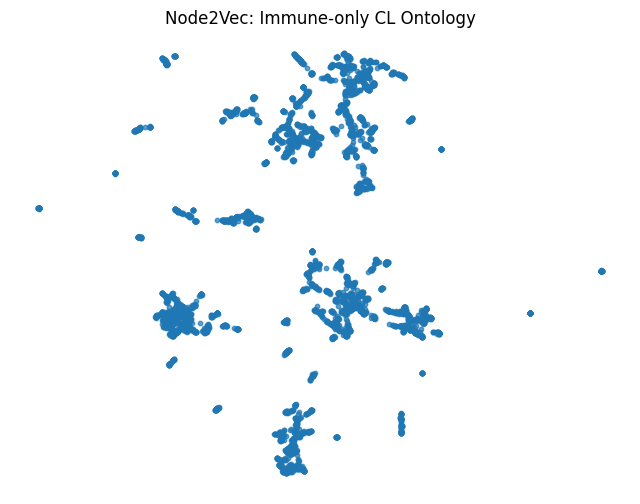

In [9]:
import umap
import matplotlib.pyplot as plt
import pandas as pd

def visualize_n2v(model, title):
    labels = list(model.wv.key_to_index.keys())
    vectors = np.array([model.wv[k] for k in labels])
    
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(vectors)

    df = pd.DataFrame({
        "x": embedding[:, 0],
        "y": embedding[:, 1],
        "label": labels,
    })

    plt.figure(figsize=(8, 6))
    plt.scatter(df["x"], df["y"], s=10, alpha=0.7)
    plt.title(title)
    plt.axis("off")
    plt.show()

visualize_n2v(n2v_immune, "Node2Vec: Immune-only CL Ontology")

In [10]:
import numpy as np

# Extract all node embeddings into a matrix
cell_names = list(n2v_immune.wv.index_to_key)   # all descendant node IDs
cell_names = [c for c in n2v_immune.wv.index_to_key if c.startswith("CL:")]

X = np.vstack([n2v_immune.wv[cell] for cell in cell_names])

In [11]:
cell_names

['CL:0000762',
 'CL:0000828',
 'CL:0000967',
 'CL:0000966',
 'CL:0000963',
 'CL:0000965',
 'CL:0000043',
 'CL:0000964',
 'CL:0002153',
 'CL:0000962',
 'CL:0002021',
 'CL:0002022',
 'CL:0000961',
 'CL:0002020',
 'CL:0002019',
 'CL:0000896',
 'CL:0000906',
 'CL:0000560',
 'CL:0002056',
 'CL:0000895',
 'CL:0000900',
 'CL:0002018',
 'CL:0000774',
 'CL:0002017',
 'CL:0002055',
 'CL:0000582',
 'CL:0000770',
 'CL:0002054',
 'CL:0002436',
 'CL:0002437',
 'CL:0019029',
 'CL:0002058',
 'CL:0002016',
 'CL:0000649',
 'CL:0002226',
 'CL:0002015',
 'CL:0002053',
 'CL:0002432',
 'CL:0002434',
 'CL:0002002',
 'CL:0000814',
 'CL:0002348',
 'CL:1000306',
 'CL:0002052',
 'CL:0000312',
 'CL:0000773',
 'CL:2000077',
 'CL:4033097',
 'CL:0000794',
 'CL:0009070',
 'CL:0000576',
 'CL:0000769',
 'CL:0000041',
 'CL:0001025',
 'CL:1001145',
 'CL:0002013',
 'CL:0002014',
 'CL:0009037',
 'CL:0002225',
 'CL:0002035',
 'CL:0002347',
 'CL:0001028',
 'CL:0002173',
 'CL:0002433',
 'CL:0002042',
 'CL:0002398',
 'CL:00020

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(X)   # shape (708, 708)

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


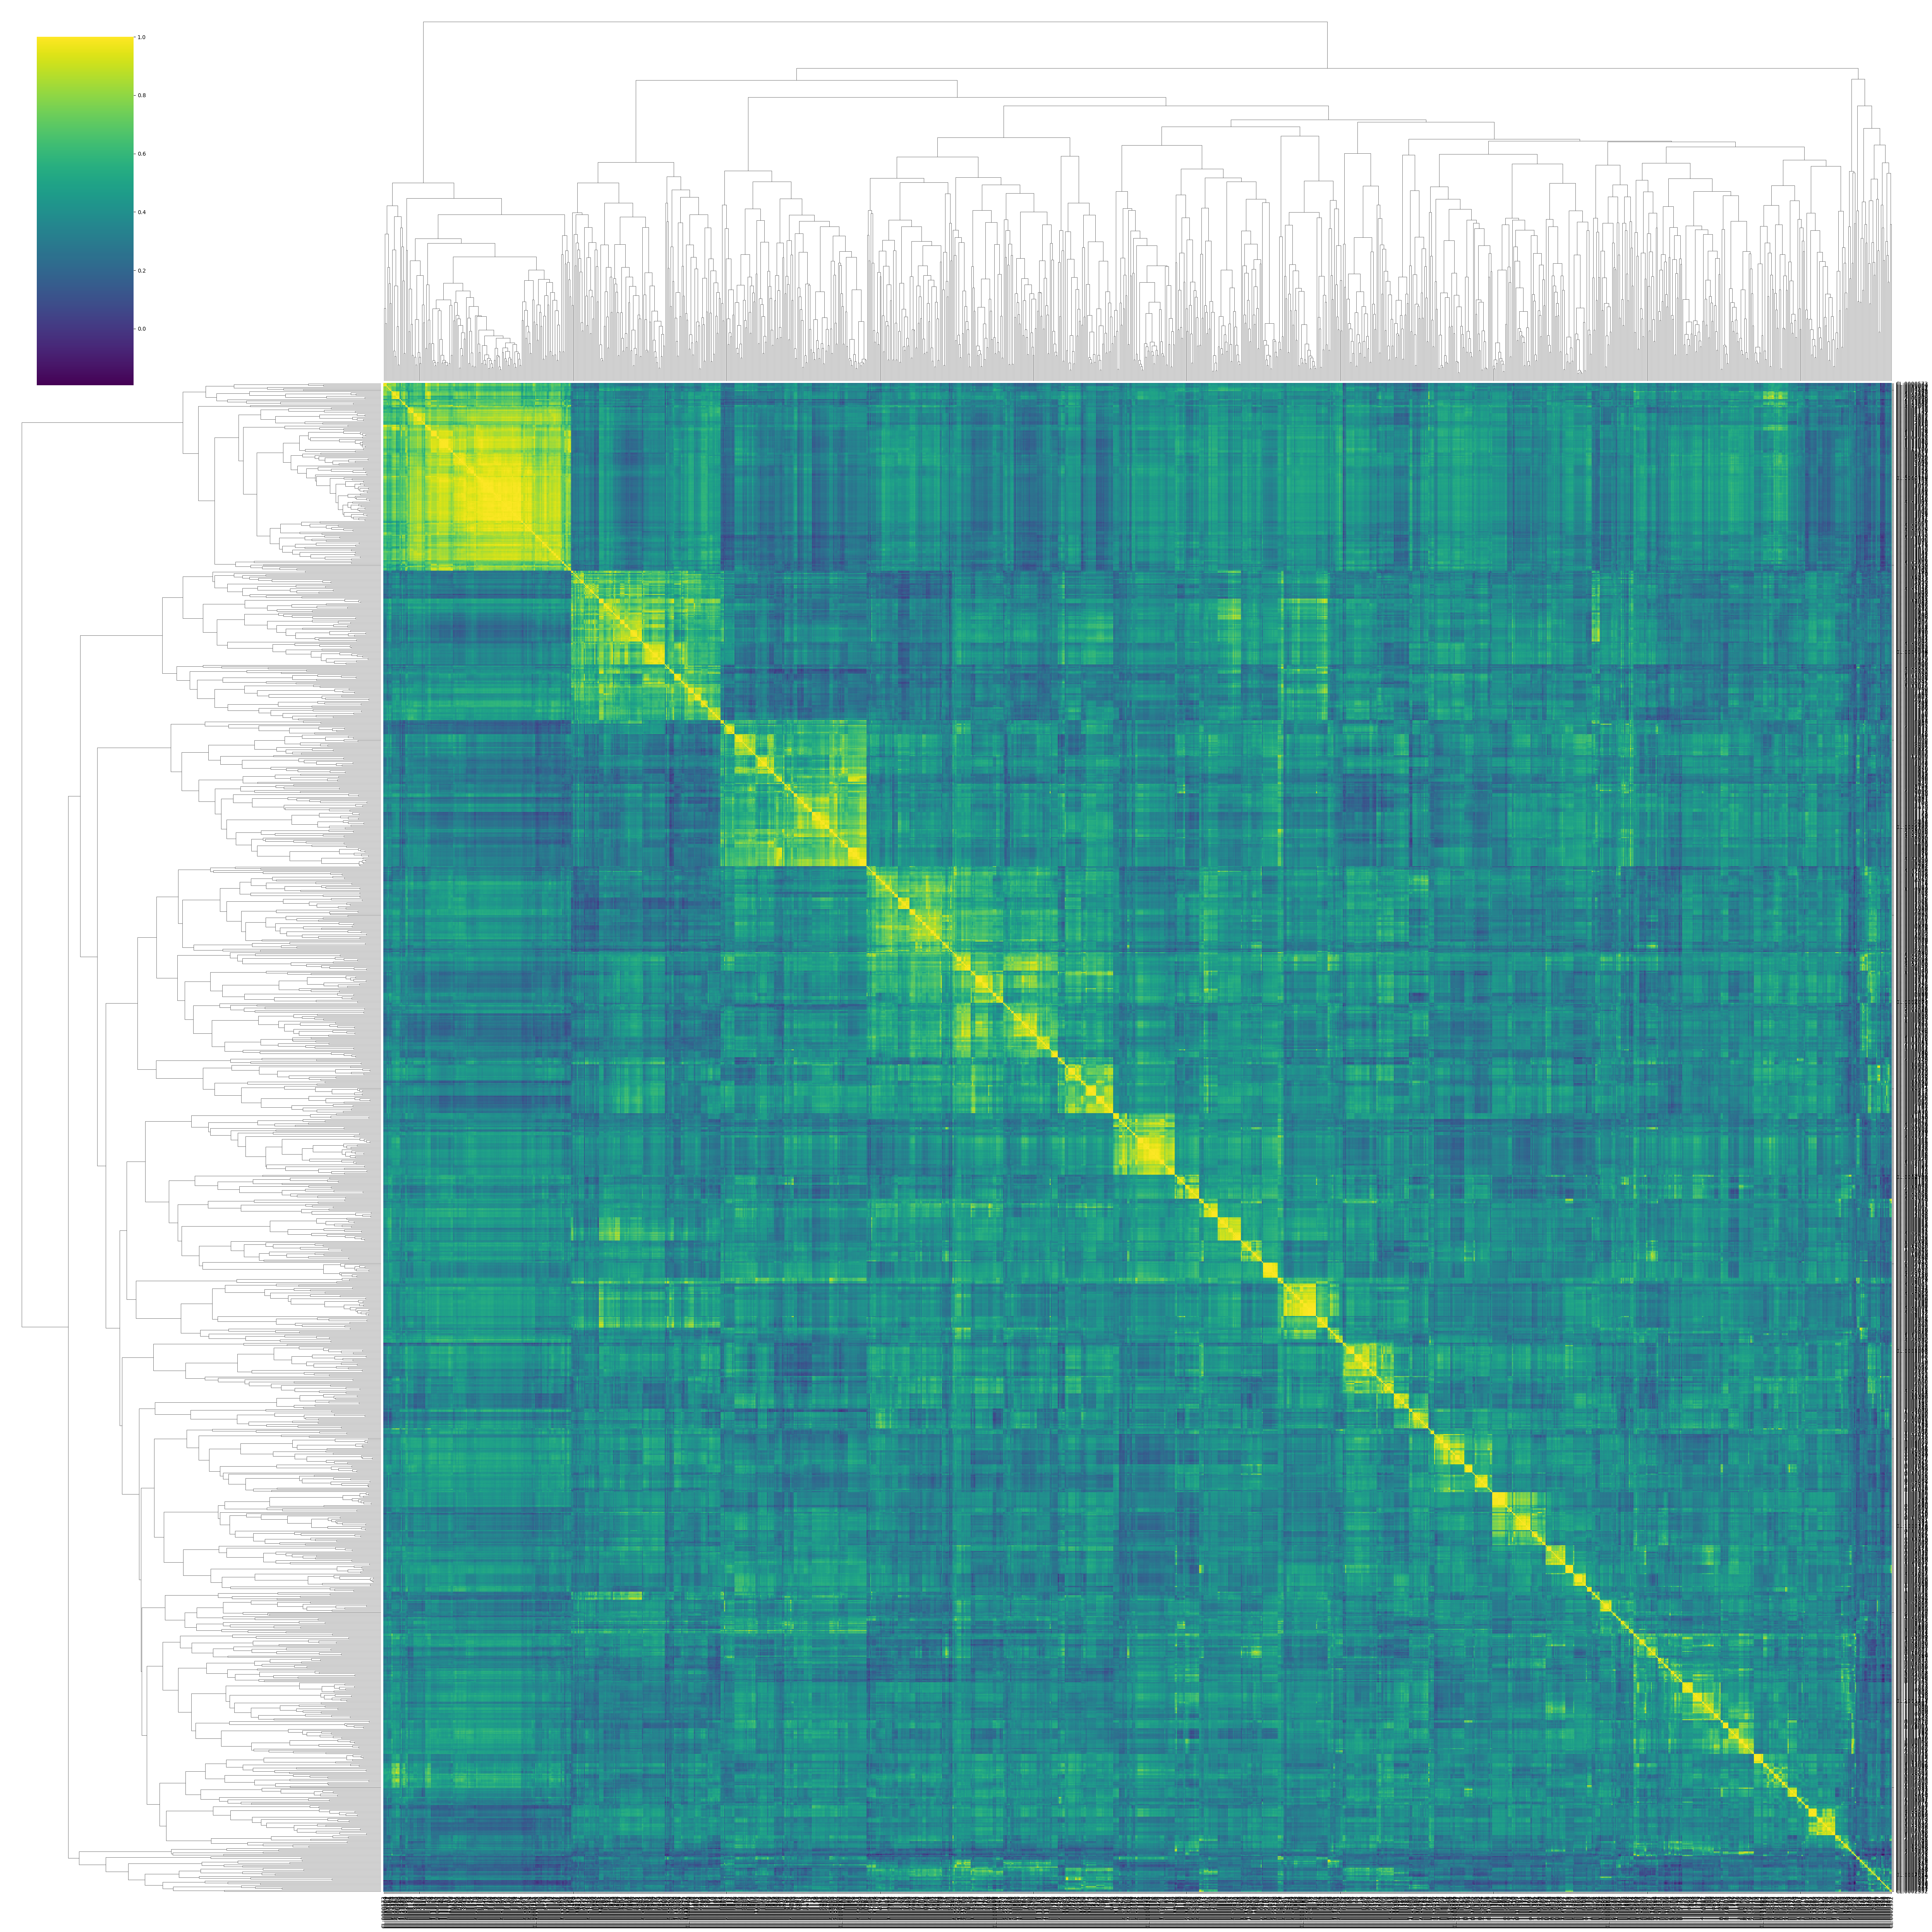

In [31]:
sns.clustermap(
    sim_matrix,
    cmap="viridis",
    figsize=(50, 50),   # scale up
    xticklabels=cell_names,
    yticklabels=cell_names
)

plt.setp(plt.gca().get_xticklabels(), rotation=90)
plt.setp(plt.gca().get_yticklabels(), rotation=0)
plt.show()

`

In [20]:
k = 5
neighbors = {}
for i, cell in enumerate(cell_names):
    topk_idx = np.argsort(-sim_matrix[i])[1:k+1]  # skip self
    neighbors[cell] = [cell_names[j] for j in topk_idx]

# Example: top neighbors of first cell
print(cell_names[0], "->", neighbors[cell_names[0]])

CL:0000762 -> ['CL:0000828', 'CL:0000050', 'CL:4033018', 'CL:0000233', 'CL:0000556']


In [22]:
# Extract ID → label mapping
id2name = {node: data.get("name", node) for node, data in immune_subgraph.nodes(data=True)}

In [23]:
import pandas as pd
import numpy as np

def export_top_neighbors(sim_matrix, cell_names, cl_graph, k=5, out_csv="neighbors.csv"):
    """
    Compute top-k cosine similarity neighbors for each ontology term
    and save results to a CSV file.

    Parameters
    ----------
    sim_matrix : np.ndarray
        Cosine similarity matrix (n x n).
    cell_names : list
        List of ontology term IDs (order matches sim_matrix).
    cl_graph : networkx.MultiDiGraph
        Graph from obonet containing 'name' attributes.
    k : int
        Number of neighbors to extract per node.
    out_csv : str
        Path to save CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame of neighbors with columns [ID, Name, Neighbor_ID, Neighbor_Name, Rank, Similarity].
    """

    # ID → name mapping
    id2name = {node: data.get("name", node) for node, data in cl_graph.nodes(data=True)}

    records = []
    for i, cell in enumerate(cell_names):
        topk_idx = np.argsort(-sim_matrix[i])[1:k+1]  # skip self
        for rank, j in enumerate(topk_idx, start=1):
            records.append({
                "ID": cell,
                "Name": id2name.get(cell, cell),
                "Neighbor_ID": cell_names[j],
                "Neighbor_Name": id2name.get(cell_names[j], cell_names[j]),
                "Rank": rank,
                "Similarity": sim_matrix[i, j]
            })

    df = pd.DataFrame(records)
    df.to_csv(out_csv, index=False)
    return df

In [24]:
df_neighbors = export_top_neighbors(sim_matrix, cell_names, cl_graph,
                                    k=5, out_csv="immune_neighbors.csv")

print(df_neighbors.head())

           ID                   Name Neighbor_ID  \
0  CL:0000762  nucleated thrombocyte  CL:0000828   
1  CL:0000762  nucleated thrombocyte  CL:0000050   
2  CL:0000762  nucleated thrombocyte  CL:4033018   
3  CL:0000762  nucleated thrombocyte  CL:0000233   
4  CL:0000762  nucleated thrombocyte  CL:0000556   

                             Neighbor_Name  Rank  Similarity  
0                             thromboblast     1    0.990008  
1  megakaryocyte-erythroid progenitor cell     2    0.808796  
2                       lung megakaryocyte     3    0.778664  
3                                 platelet     4    0.744929  
4                            megakaryocyte     5    0.732588  


In [25]:
import scanpy as sc

adata = sc.read("../data/cellxgene_data/immune_1M_merged.h5ad", backed="r")

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [33]:
immune_ids = [node for node in immune_subgraph if "CL:" in node]
len(immune_ids)

1302

In [ ]:
# Build ID → name mapping from ontology graph
id2name = {node: data.get("name", node) for node, data in cl_graph.nodes(data=True)}

# Unique ontology IDs in AnnData
adata_ids = set(adata.obs["cell_type_ontology_term_id"].unique())

# Intersect with immune subtree IDs
immune_in_adata = adata_ids.intersection(immune_ids)

print("Unique immune IDs in adata:", len(immune_in_adata))

# Print sorted list of IDs with names
for cid in sorted(list(immune_in_adata)):  # peek first 10
    print(cid, "->", id2name.get(cid, "N/A"))

effector memory CD4-positive, alpha-beta T cell
central memory CD4-positive, alpha-beta T cell
gamma-delta T cell
classical monocyte
effector memory CD8-positive, alpha-beta T cell, terminally differentiated
naive thymus-derived CD4-positive, alpha-beta T cell
naive B cell
non-classical monocyte
memory B cell
natural killer cell
myeloid dendritic cell
CD4-positive, alpha-beta T cell
plasmablast
naive thymus-derived CD8-positive, alpha-beta T cell
CD8-positive, alpha-beta memory T cell
smooth muscle cell
fibroblast
pulmonary alveolar type 2 cell
endothelial cell
ciliated cell
endothelial cell of lymphatic vessel
pulmonary alveolar type 1 cell
epithelial cell of lower respiratory tract
pericyte
effector CD8-positive, alpha-beta T cell
IgG-negative class switched memory B cell
CD8-positive, alpha-beta T cell
CD4-positive helper T cell
IgG memory B cell
erythrocyte
intermediate monocyte
platelet
dendritic cell
effector CD4-positive, alpha-beta T cell
blood cell
CD8-positive, alpha-beta thy